# Загрузка данных

In [39]:
import pandas as pd
import numpy as np

In [104]:
pd.set_option('display.max_columns', None)

In [41]:
df = pd.read_excel('../data/suspension_experiments.xlsx', sheet_name=None)

In [42]:
df.keys()

dict_keys(['Протокол экспериментов', 'Суспензии', 'Подложки'])

In [43]:
df['Подложки']['Смачиваемость подложки'].unique()

array([nan, 'Лиофильная', 'Нейтральная', 'Лиофобная'], dtype=object)

In [44]:
df['Подложки']['Смачиваемость подложки'] = df['Подложки']['Смачиваемость подложки'].map(
        {
        'Лиофильная': 'lyophilic',
        'Нейтральная': 'neutral',
        'Лиофобная': 'lyophobic'
    }
)

In [45]:
df_susp_exp = pd.merge(pd.merge(
    df['Протокол экспериментов'], df['Суспензии'], 
    on="Код суспензии", how='left'
), df['Подложки'], on="Код подложки", how='left')
df_susp_exp = df_susp_exp[
    df_susp_exp['Тест №']!=1
]
df_susp_exp.head()

,Тест №,Код подложки,Код суспензии,"Напряжение, В","Длительность больших импульсов, мс","Высота генератора над подложкой, м","Угол наклона, °","Режим генерации [0 - капель нет, 1 - одиночная капля, 2 - несколько капель]","Диаметр капли, мм",Плотность среды,Поверхностное натяжение среды,Динамическая вязкость среды,Средний диаметр частиц,Соотношение плотности частиц и плотности среды,Концентрация (объёмная доля) частиц внутри капель,Смачиваемость подложки,Шероховатость поверхности подложки
4,2,черновая,S1,105.0,10.0,0.8,0,1.0,3.12,0.82,26.9,6.79,0.0415,1.219512,0.08,NaN,NaN
5,3,W1,S1,105.0,10.0,0.8,0,1.0,NaN,0.82,26.9,6.79,0.0415,1.219512,0.08,lyophilic,0.1
6,4,W1,S1,105.0,10.0,0.8,0,1.0,NaN,0.82,26.9,6.79,0.0415,1.219512,0.08,lyophilic,0.1
7,5,W1,S1,105.0,10.0,0.8,0,1.0,NaN,0.82,26.9,6.79,0.0415,1.219512,0.08,lyophilic,0.1
8,6,черновая,DS1,121.5,12.0,0.8,0,1.0,3.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
df_data = pd.read_excel('../data/data_target.xlsx', index_col=[0])
df_data.head()

,Test #,Total number of dropped drops,splashing,breaking_up,net_impact,rebound
2,2,1,1,0,0,0
3,3,1,1,0,0,0
4,4,1,1,0,0,0
5,5,1,1,0,0,0
6,6,1,1,0,0,0


In [47]:
df_merged = df_data.merge(df_susp_exp, left_on='Test #', right_on='Тест №', how='left')
df_merged.head()

,Test #,Total number of dropped drops,splashing,breaking_up,net_impact,rebound,Тест №,Код подложки,Код суспензии,"Напряжение, В","Длительность больших импульсов, мс","Высота генератора над подложкой, м","Угол наклона, °","Режим генерации [0 - капель нет, 1 - одиночная капля, 2 - несколько капель]","Диаметр капли, мм",Плотность среды,Поверхностное натяжение среды,Динамическая вязкость среды,Средний диаметр частиц,Соотношение плотности частиц и плотности среды,Концентрация (объёмная доля) частиц внутри капель,Смачиваемость подложки,Шероховатость поверхности подложки
0,2,1,1,0,0,0,2,черновая,S1,105.0,10.0,0.8,0,1.0,3.12,0.82,26.9,6.79,0.0415,1.219512,0.08,NaN,NaN
1,3,1,1,0,0,0,3,W1,S1,105.0,10.0,0.8,0,1.0,NaN,0.82,26.9,6.79,0.0415,1.219512,0.08,lyophilic,0.1
2,4,1,1,0,0,0,4,W1,S1,105.0,10.0,0.8,0,1.0,NaN,0.82,26.9,6.79,0.0415,1.219512,0.08,lyophilic,0.1
3,5,1,1,0,0,0,5,W1,S1,105.0,10.0,0.8,0,1.0,NaN,0.82,26.9,6.79,0.0415,1.219512,0.08,lyophilic,0.1
4,6,1,1,0,0,0,6,черновая,DS1,121.5,12.0,0.8,0,1.0,3.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Преобразование режима генерации

In [48]:
df_merged['Режим генерации [0 - капель нет, 1 - одиночная капля, 2 - несколько капель]'].unique()

array([ 1.,  2., nan])

In [49]:
df_merged.rename(
    columns={
        'Режим генерации [0 - капель нет, 1 - одиночная капля, 2 - несколько капель]': 'Режим генерации'
    }, inplace=True
)

In [50]:
df_merged.loc[
    df_merged['Режим генерации']!=1,
    'Режим генерации'
] = 0

In [51]:
df_merged.columns

Index(['Test #', 'Total number of dropped drops', 'splashing', 'breaking_up',
       'net_impact', 'rebound', 'Тест №', 'Код подложки', 'Код суспензии',
       'Напряжение, В', 'Длительность больших импульсов, мс',
       'Высота генератора над подложкой, м', 'Угол наклона, °',
       'Режим генерации', 'Диаметр капли, мм', 'Плотность среды',
       'Поверхностное натяжение среды', 'Динамическая вязкость среды',
       'Средний диаметр частиц',
       'Соотношение плотности частиц и плотности среды',
       'Концентрация (объёмная доля) частиц внутри капель',
       'Смачиваемость подложки', 'Шероховатость поверхности подложки'],
      dtype='object')

In [52]:
df_merged[['Режим генерации', 'Total number of dropped drops']] = df_merged[['Режим генерации', 'Total number of dropped drops']].astype(int)

In [53]:
# mask = ~np.all(df_merged[['Режим генерации', 'Total number of dropped drops']], axis=1)
mask = df_merged['Режим генерации'] != df_merged['Total number of dropped drops']
df_merged[mask].shape

(6, 23)

In [54]:
df_merged['Режим генерации'].unique()

array([1, 0])

In [55]:
df_merged['Total number of dropped drops'].unique()

array([1, 0])

In [56]:
df_merged[
    (df_merged['Режим генерации']==0) &
    (df_merged['Total number of dropped drops']==1)
].shape

(0, 23)

In [57]:
df_merged[
    (df_merged['Режим генерации']==1) &
    (df_merged['Total number of dropped drops']==0)
].shape

(6, 23)

# Переименование колонок

In [58]:
df.keys()

dict_keys(['Протокол экспериментов', 'Суспензии', 'Подложки'])

In [59]:
df['Протокол экспериментов'].columns

Index(['Тест №', 'Код подложки', 'Код суспензии', 'Напряжение, В',
       'Длительность больших импульсов, мс',
       'Высота генератора над подложкой, м', 'Угол наклона, °',
       'Режим генерации [0 - капель нет, 1 - одиночная капля, 2 - несколько капель]',
       'Диаметр капли, мм'],
      dtype='object')

In [60]:
df_merged.columns

Index(['Test #', 'Total number of dropped drops', 'splashing', 'breaking_up',
       'net_impact', 'rebound', 'Тест №', 'Код подложки', 'Код суспензии',
       'Напряжение, В', 'Длительность больших импульсов, мс',
       'Высота генератора над подложкой, м', 'Угол наклона, °',
       'Режим генерации', 'Диаметр капли, мм', 'Плотность среды',
       'Поверхностное натяжение среды', 'Динамическая вязкость среды',
       'Средний диаметр частиц',
       'Соотношение плотности частиц и плотности среды',
       'Концентрация (объёмная доля) частиц внутри капель',
       'Смачиваемость подложки', 'Шероховатость поверхности подложки'],
      dtype='object')

In [61]:
new_names = ['test', 'substrate', 'suspension', 'voltage', 
             'long_impulse_duration', 'height', 'inclination', 
             'generation_mode', 'droplet_diameter'
]

dict_rename = {key: new_names[i] for i, key in enumerate(df['Протокол экспериментов'].columns)}
df_merged.rename(columns=dict_rename, inplace=True)

In [62]:
new_names = [
    'suspension', 'liquid_density', 'surface_tension', 
    'viscosity', 'particle_mean_diameter', 'particle_liquid_density_ratio', 
    'volume_fraction'
]
dict_rename = {key: new_names[i] for i, key in enumerate(df['Суспензии'].columns)}
df_merged.rename(columns=dict_rename, inplace=True)

In [63]:
new_names = [
    'substrate', 'wettability', 'roughness'
]
dict_rename = {key: new_names[i] for i, key in enumerate(df['Подложки'].columns)}
df_merged.rename(columns=dict_rename, inplace=True)

In [64]:
df_merged.head()

,Test #,Total number of dropped drops,splashing,breaking_up,net_impact,rebound,test,substrate,suspension,voltage,long_impulse_duration,height,inclination,Режим генерации,droplet_diameter,liquid_density,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,volume_fraction,wettability,roughness
0,2,1,1,0,0,0,2,черновая,S1,105.0,10.0,0.8,0,1,3.12,0.82,26.9,6.79,0.0415,1.219512,0.08,NaN,NaN
1,3,1,1,0,0,0,3,W1,S1,105.0,10.0,0.8,0,1,NaN,0.82,26.9,6.79,0.0415,1.219512,0.08,lyophilic,0.1
2,4,1,1,0,0,0,4,W1,S1,105.0,10.0,0.8,0,1,NaN,0.82,26.9,6.79,0.0415,1.219512,0.08,lyophilic,0.1
3,5,1,1,0,0,0,5,W1,S1,105.0,10.0,0.8,0,1,NaN,0.82,26.9,6.79,0.0415,1.219512,0.08,lyophilic,0.1
4,6,1,1,0,0,0,6,черновая,DS1,121.5,12.0,0.8,0,1,3.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
df_merged.rename(columns={'Total number of dropped drops': 'one_drop'}, inplace=True)

In [66]:
df_merged.columns

Index(['Test #', 'one_drop', 'splashing', 'breaking_up', 'net_impact',
       'rebound', 'test', 'substrate', 'suspension', 'voltage',
       'long_impulse_duration', 'height', 'inclination', 'Режим генерации',
       'droplet_diameter', 'liquid_density', 'surface_tension', 'viscosity',
       'particle_mean_diameter', 'particle_liquid_density_ratio',
       'volume_fraction', 'wettability', 'roughness'],
      dtype='object')

In [67]:
df_merged.drop('test', axis=1, inplace=True)
df_merged.rename(
    columns={
        'Test #': 'test'
    }, inplace=True
)

In [68]:
df_merged.to_excel('../data/df_merged.xlsx')

# Profiler

In [69]:
from pandas_profiling import ProfileReport

profile = ProfileReport(df_merged, title='Droplets EDA')
profile.to_file('../data/report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Feature analysis

## Data understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('../data/df_merged.xlsx', index_col=[0])

#### Data Preparation  2. b. ii. Пропуск в колонках liquid

In [3]:
mask = df['liquid_density'].isna()
df[mask]

,test,one_drop,splashing,breaking_up,net_impact,rebound,substrate,suspension,voltage,long_impulse_duration,...,Режим генерации,droplet_diameter,liquid_density,surface_tension,viscosity,particle_mean_diameter,particle_liquid_density_ratio,volume_fraction,wettability,roughness
4,6,1,1,0,0,0,черновая,DS1,121.5,12,...,1,3.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2. b. ii. Построить завис. Droplet diameter от voltage в разрезе suspension

In [4]:
df.columns

Index(['test', 'one_drop', 'splashing', 'breaking_up', 'net_impact', 'rebound',
       'substrate', 'suspension', 'voltage', 'long_impulse_duration', 'height',
       'inclination', 'Режим генерации', 'droplet_diameter', 'liquid_density',
       'surface_tension', 'viscosity', 'particle_mean_diameter',
       'particle_liquid_density_ratio', 'volume_fraction', 'wettability',
       'roughness'],
      dtype='object')

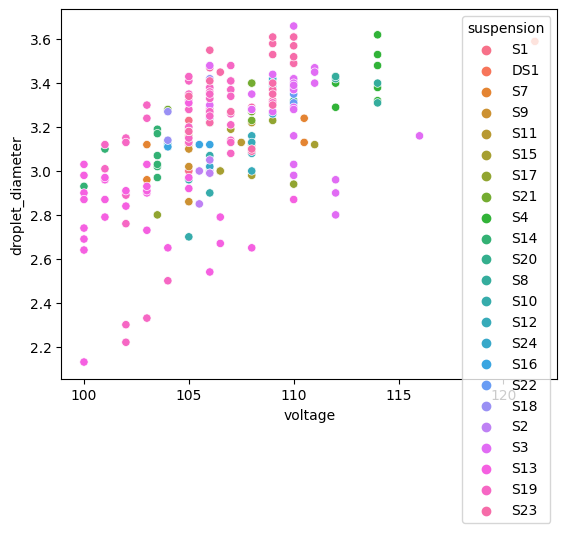

<Figure size 4000x4000 with 0 Axes>

In [5]:
sns.scatterplot(df, x='voltage', y='droplet_diameter', hue='suspension')
plt.figure(figsize=(40, 40))
plt.show()

## Data preparation

### 1. b. i.

In [6]:
df['substrate'].unique()

array(['черновая', 'W1', 'W2', 'W3',
       'черновая подложка W3 алюминиевая сторона', 'W4',
       'черновая подложка W3, сторона с покрытием'], dtype=object)

In [7]:
df_edited = df[
    ~df['substrate'].isin(['черновая', 
    'черновая подложка W3 алюминиевая сторона',
    'черновая подложка W3, сторона с покрытием'])
].copy()

### 1. b. iii. Long_imp_dur - возможно стоит объединить 18 и 21 -> 15

In [8]:
df['long_impulse_duration'].unique()

array([10, 12, 18, 21, 15], dtype=int64)

In [9]:
df_edited.loc[
    df['long_impulse_duration'].isin([18, 21]),
    'long_impulse_duration'
] = 15

### 1. b. iv. Дропаем режим генерации

In [10]:
df_edited.drop(columns=['Режим генерации'], axis=1, inplace=True)

### 2. a. i. Droplet_diameter - , зап-е можно вести по признакам suspension, voltage, long impulse duration, height. Есть подобный метод в fillna. Следующий метод - fillna(ffill), пропуски можно заполнить предыд. Зн-ми.

In [11]:
df_edited.columns

Index(['test', 'one_drop', 'splashing', 'breaking_up', 'net_impact', 'rebound',
       'substrate', 'suspension', 'voltage', 'long_impulse_duration', 'height',
       'inclination', 'droplet_diameter', 'liquid_density', 'surface_tension',
       'viscosity', 'particle_mean_diameter', 'particle_liquid_density_ratio',
       'volume_fraction', 'wettability', 'roughness'],
      dtype='object')

In [12]:
df_drop_mean = pd.DataFrame(df_edited[
    [
        'suspension', 'voltage', 
        'long_impulse_duration', 'height', 'droplet_diameter'
     ]
].drop_duplicates().dropna().groupby(['suspension', 'voltage', 
        'long_impulse_duration', 'height']
)['droplet_diameter'].mean()).reset_index()
df_drop_mean.head()

,suspension,voltage,long_impulse_duration,height,droplet_diameter
0,S1,105.0,10,0.8,3.1200
1,S10,105.0,15,0.8,2.8300
2,S10,106.0,12,0.8,2.9975
3,S11,107.5,10,0.8,3.1300
4,S11,108.0,10,0.8,3.1300


In [13]:
for i in range(df_drop_mean.shape[0]):
    mean_str = df_drop_mean.iloc[i]
    df_edited.loc[
        (df_edited['suspension']==mean_str['suspension']) &
        (df_edited['voltage']==mean_str['voltage']) &
        (df_edited['long_impulse_duration']==mean_str['long_impulse_duration']) &
        (df_edited['height']==mean_str['height']),
        'droplet_diameter'
    ] = mean_str['droplet_diameter']

In [14]:
# индексы isna и предыдущие значения
indexes_isna = df_edited[df_edited['droplet_diameter'].isna()].index
all_indexes = sorted(list(set(np.hstack([[i-1, i] for i in indexes_isna]))))
indexes = sorted(list(set(all_indexes) & set(df_edited.index)))
df_edited.loc[indexes]['droplet_diameter']

19     3.240000
20          NaN
21          NaN
22          NaN
23          NaN
24          NaN
33     3.035000
34          NaN
39     3.130000
40          NaN
47     3.000000
48          NaN
49          NaN
50     3.120000
51          NaN
52     2.980000
53          NaN
60     3.230000
61          NaN
64          NaN
68     2.800000
69          NaN
85     3.380000
86          NaN
87          NaN
154    3.115000
155         NaN
156         NaN
157         NaN
158         NaN
159         NaN
237    3.056667
238         NaN
239         NaN
240         NaN
265    3.391667
266         NaN
281    3.356000
282         NaN
283         NaN
312    3.547500
313         NaN
317    3.461667
318         NaN
319         NaN
325    3.390000
326         NaN
335    3.300000
336         NaN
Name: droplet_diameter, dtype: float64

In [15]:
df_edited.loc[indexes].to_excel('../data/df_na.xlsx')

### 2. a. ii. Part liq des rat - про missing в liquid смотри выше

### 2. b. i. Volume fraction - объединить 0.04 и 0.05, а также 0.08 и 0.1


In [16]:
df_edited['volume_fraction'].unique()

array([0.08, 0.1 , 0.04, 0.05])

In [17]:
df_edited['volume_fraction_binary'] = 0
df_edited.loc[
    df_edited['volume_fraction'].isin([0.08, 0.1]),
    'volume_fraction_binary'
] = 1

### 3. c. Кодирование категориальных признаков
Liquid density, surface tension, viscosity, particle mean diam - Ordinal encoder
Wettability - ordinal enc

In [18]:
from sklearn.preprocessing import OrdinalEncoder

In [19]:
df_edited.columns

Index(['test', 'one_drop', 'splashing', 'breaking_up', 'net_impact', 'rebound',
       'substrate', 'suspension', 'voltage', 'long_impulse_duration', 'height',
       'inclination', 'droplet_diameter', 'liquid_density', 'surface_tension',
       'viscosity', 'particle_mean_diameter', 'particle_liquid_density_ratio',
       'volume_fraction', 'wettability', 'roughness',
       'volume_fraction_binary'],
      dtype='object')

In [22]:
enc = OrdinalEncoder()
df_edited[
        [
        'liquid_density', 'surface_tension',
        'viscosity', 'particle_mean_diameter'
    ]
] = enc.fit_transform(
    df_edited[
    [
        'liquid_density', 'surface_tension',
        'viscosity', 'particle_mean_diameter'
    ]
])

In [20]:
df_edited.to_excel('../data/df_merged_edited.xlsx')